```Upload your ZIP file```

In [1]:
from google.colab import files
uploaded = files.upload()

Saving drive-download-20260327T132339Z-1-001.zip to drive-download-20260327T132339Z-1-001.zip


```Extract ZIP```

In [2]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('data')

print("Extracted files:", os.listdir('data'))

Extracted files: ['feb_first_half-dept.csv', 'jan_sec_half-dept.csv', 'jan_sec_half-dept.xlsx', 'june_sec_half-dept.csv', 'jan_first_half-dept.csv', 'feb_sec_half-dept.csv', 'june_first_half-dept.csv', 'april_first_half-dept.csv', 'march_sec_half-dept.csv', 'april_sec_half-dept.csv', 'may_sec_half-dept.csv', 'may_first_half-dept.csv', 'march_first_half-dept.csv']


```Install libraries```

In [3]:
!pip install pandas scikit-learn joblib

```Load & combine all CSV files```

In [4]:
import pandas as pd
import os

DATA_PATH = "data"

all_files = [f for f in os.listdir(DATA_PATH) if f.endswith(".csv")]

df_list = []
for file in all_files:
    df = pd.read_csv(os.path.join(DATA_PATH, file))
    df_list.append(df)

data = pd.concat(df_list, ignore_index=True)

print(data.head())
print("Shape:", data.shape)

         date  department  monthly_budget  expense_limit  head_count  \
0  2024-02-01     Finance          477622          10000          50   
1  2024-02-01          IT          676046          15000          50   
2  2024-02-01          HR          319271           8000          50   
3  2024-02-01  Operations          616097          12000          50   
4  2024-02-02     Finance          524164          10000          50   

   avg_transaction  
0             3201  
1             5709  
2             3453  
3             4723  
4             5578  
Shape: (724, 6)


```Preprocess data```

In [5]:
from sklearn.preprocessing import LabelEncoder

# Convert date
data['date'] = pd.to_datetime(data['date'])
data['day'] = data['date'].dt.day
data['month'] = data['date'].dt.month

# Encode department
le = LabelEncoder()
data['department'] = le.fit_transform(data['department'])

# Select features
features = [
    'monthly_budget',
    'expense_limit',
    'head_count',
    'avg_transaction',
    'day',
    'month',
    'department'
]

X = data[features]

```Train Isolation Forest```

In [6]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

model.fit(X)

print("Model trained ✅")

Model trained ✅


```Detect anomalies```

In [7]:
data['anomaly'] = model.predict(X)

# Convert labels
data['anomaly'] = data['anomaly'].map({1: 0, -1: 1})

print(data.head())

        date  department  monthly_budget  expense_limit  head_count  \
0 2024-02-01           0          477622          10000          50   
1 2024-02-01           2          676046          15000          50   
2 2024-02-01           1          319271           8000          50   
3 2024-02-01           3          616097          12000          50   
4 2024-02-02           0          524164          10000          50   

   avg_transaction  day  month  anomaly  
0             3201    1      2        0  
1             5709    1      2        0  
2             3453    1      2        0  
3             4723    1      2        0  
4             5578    2      2        0  


```See anomalies```

In [8]:
anomalies = data[data['anomaly'] == 1]

print("Total anomalies:", len(anomalies))
anomalies.head()

Total anomalies: 37


,date,department,monthly_budget,expense_limit,head_count,avg_transaction,day,month,anomaly
9,2024-02-03,2,717749,15000,50,2095,3,2,1
105,2024-01-27,2,761800,15000,50,5728,27,1,1
113,2024-01-29,2,742210,15000,50,3051,29,1,1
114,2024-01-29,1,325526,8000,50,2793,29,1,1
117,2024-01-30,2,734064,15000,50,5960,30,1,1


```anomaly score```

In [9]:
data['anomaly_score'] = model.decision_function(X)
data['anomaly_label'] = model.predict(X)

# Convert labels
data['anomaly_label'] = data['anomaly_label'].map({1: 0, -1: 1})

In [10]:
data_sorted = data.sort_values(by='anomaly_score')

data_sorted.head(10)   # Top anomalies

,date,department,monthly_budget,expense_limit,head_count,avg_transaction,day,month,anomaly,anomaly_score,anomaly_label
298,2024-06-01,1,296306,8000,50,5996,1,6,1,-0.035797,1
174,2024-06-28,1,306906,8000,50,2034,28,6,1,-0.028952,1
189,2024-01-02,2,712136,15000,50,2204,2,1,1,-0.028037,1
574,2024-05-24,1,285154,8000,50,2073,24,5,1,-0.027558,1
194,2024-01-03,1,317777,8000,50,2044,3,1,1,-0.023142,1
117,2024-01-30,2,734064,15000,50,5960,30,1,1,-0.022733,1
178,2024-06-29,1,295398,8000,50,5887,29,6,1,-0.021598,1
187,2024-01-01,3,585848,12000,50,5711,1,1,1,-0.021480,1
120,2024-01-31,0,476445,10000,50,2342,31,1,1,-0.019442,1
172,2024-06-28,0,496013,10000,50,5942,28,6,1,-0.017174,1


```Normalize features```

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
model.fit(X_scaled)

IsolationForest(contamination=0.05, random_state=42)

```Tune contamination automatically```

In [13]:
for c in [0.01, 0.03, 0.05, 0.1]:
    model = IsolationForest(contamination=c, random_state=42)
    model.fit(X_scaled)
    preds = model.predict(X_scaled)

    anomaly_count = (preds == -1).sum()
    print(f"Contamination={c} → Anomalies={anomaly_count}")

Contamination=0.01 → Anomalies=8
Contamination=0.03 → Anomalies=22
Contamination=0.05 → Anomalies=37
Contamination=0.1 → Anomalies=73


```Feature engineering```

In [14]:
# Budget utilization ratio
data['budget_utilization'] = data['avg_transaction'] / data['expense_limit']

# Per employee cost
data['cost_per_employee'] = data['monthly_budget'] / data['head_count']

In [15]:
features = [
    'monthly_budget',
    'expense_limit',
    'head_count',
    'avg_transaction',
    'budget_utilization',
    'cost_per_employee',
    'day',
    'month',
    'department'
]

```Visualize anomalies```

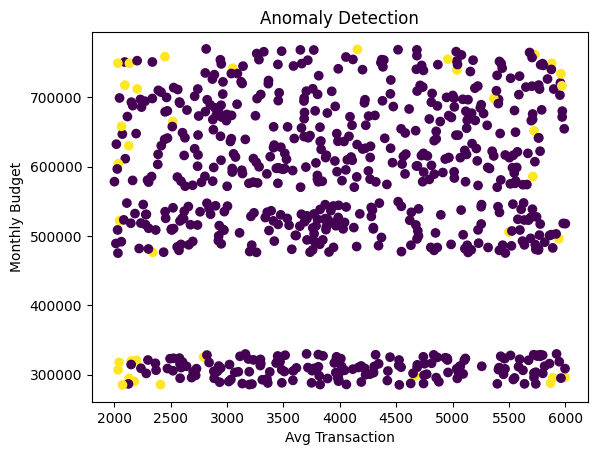

In [16]:
import matplotlib.pyplot as plt

plt.scatter(data['avg_transaction'], data['monthly_budget'],
            c=data['anomaly_label'])

plt.xlabel("Avg Transaction")
plt.ylabel("Monthly Budget")
plt.title("Anomaly Detection")
plt.show()

```Save models```

In [17]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [18]:
# 1. Scale
X_scaled = scaler.fit_transform(X)

# 2. Train
model = IsolationForest(n_estimators=200, contamination=0.03, random_state=42)
model.fit(X_scaled)

# 3. Score
data['score'] = model.decision_function(X_scaled)
data['anomaly'] = model.predict(X_scaled)
data['anomaly'] = data['anomaly'].map({1: 0, -1: 1})

# 4. Sort
data = data.sort_values(by='score')

##Testing phase

```Upload CSV in Colab```

In [21]:
from google.colab import files
uploaded = files.upload()

Saving test_data.csv to test_data (1).csv


```Load uploaded file```

In [22]:
import pandas as pd

file_name = list(uploaded.keys())[0]

# If CSV
if file_name.endswith(".csv"):
    data = pd.read_csv(file_name)

# If ZIP (multiple CSVs)
elif file_name.endswith(".zip"):
    import zipfile, os

    with zipfile.ZipFile(file_name, 'r') as zip_ref:
        zip_ref.extractall("data")

    all_files = [f for f in os.listdir("data") if f.endswith(".csv")]

    df_list = []
    for f in all_files:
        df = pd.read_csv(os.path.join("data", f))
        df_list.append(df)

    data = pd.concat(df_list, ignore_index=True)

print("Data loaded:", data.shape)
data.head()

Data loaded: (100, 6)


,date,department,monthly_budget,expense_limit,head_count,avg_transaction
0,2024-05-20,HR,431932,12000,50,3095
1,2024-05-21,Finance,354886,10000,58,3238
2,2024-05-11,HR,674871,8000,43,4919
3,2024-05-03,Operations,629365,8000,41,4391
4,2024-05-06,Operations,499041,15000,40,2459


```FULL PIPELINE```

In [24]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

# ======================
# CLEAN (optional safety)
# ======================
data = data.dropna()

# ======================
# FEATURE ENGINEERING
# ======================
data['date'] = pd.to_datetime(data['date'])
data['day'] = data['date'].dt.day
data['month'] = data['date'].dt.month

# Encode department
le = LabelEncoder()
data['department'] = le.fit_transform(data['department'])

# Smart features
data['budget_utilization'] = data['avg_transaction'] / data['expense_limit']
data['cost_per_employee'] = data['monthly_budget'] / data['head_count']

# ======================
# FEATURES
# ======================
features = [
    'monthly_budget',
    'expense_limit',
    'head_count',
    'avg_transaction',
    'budget_utilization',
    'cost_per_employee',
    'day',
    'month',
    'department'
]

X = data[features]

# ======================
# SCALING
# ======================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ======================
# MODEL
# ======================
model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

model.fit(X_scaled)

# ======================
# PREDICTION + SCORE
# ======================
data['anomaly_score'] = model.decision_function(X_scaled)
data['anomaly'] = model.predict(X_scaled)

data['anomaly'] = data['anomaly'].map({1: 0, -1: 1})

# ======================
# SORT
# ======================
data = data.sort_values(by='anomaly_score')

# ======================
# RESULTS
# ======================

display(data.head(5))

print("\n✅ Total anomalies:", data['anomaly'].sum())

,date,department,monthly_budget,expense_limit,head_count,avg_transaction,day,month,budget_utilization,cost_per_employee,anomaly_score,anomaly
95,2024-05-15,2,2500000,15000,3,40000,15,5,2.666667,833333.333333,-0.129872,1
93,2024-05-13,3,3000000,12000,20,30000,13,5,2.500000,150000.000000,-0.079073,1
91,2024-05-11,2,2000000,15000,5,25000,11,5,1.666667,400000.000000,-0.066102,1
98,2024-05-18,0,1800000,10000,8,22000,18,5,2.200000,225000.000000,-0.044355,1
94,2024-05-14,0,50000,10000,200,50,14,5,0.005000,250.000000,-0.007362,1



✅ Total anomalies: 5
